通过营销活动的样本数据，分析营销活动效果，找到高目标群体，对客户分群，采用不同营销策略

In [49]:
import pandas as pd
import numpy as np

data = pd.read_csv(r"D:\pythonfiles\__pycache__\电商营销活动分析\data.csv")

print("数据前五行：\n",data.head())

数据前五行：
    recency  history  used_discount  used_bogo   zip_code  is_referral channel  \
0       10   142.44              1          0  Surburban            0   Phone   
1        6   329.08              1          1      Rural            1     Web   
2        7   180.65              0          1  Surburban            1     Web   
3        9   675.83              1          0      Rural            1     Web   
4        2    45.34              1          0      Urban            0     Web   

             offer  conversion  
0  Buy One Get One           0  
1         No Offer           0  
2  Buy One Get One           0  
3         Discount           0  
4  Buy One Get One           0  


列描述
recency      ：上此购买距现在月数
history      ：历史购买金额
used_discount：是否使用折扣
used_bogo    ：是否使用买一送一
zip_code     ：区域
is_referral  ：是否有推荐
channel      ：渠道
offer        ：营销优惠

In [39]:
data.info()   #获取数据的基本信息，包括数据类型、非空值数量等
data.describe()  #获取数据的统计信息，包括均值、标准差、最小值、最大值等

<class 'pandas.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   recency        64000 non-null  int64  
 1   history        64000 non-null  float64
 2   used_discount  64000 non-null  int64  
 3   used_bogo      64000 non-null  int64  
 4   zip_code       64000 non-null  str    
 5   is_referral    64000 non-null  int64  
 6   channel        64000 non-null  str    
 7   offer          64000 non-null  str    
 8   conversion     64000 non-null  int64  
dtypes: float64(1), int64(5), str(3)
memory usage: 4.4 MB


,recency,history,used_discount,used_bogo,is_referral,conversion
count,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000
mean,5.763734,242.085656,0.551031,0.549719,0.502250,0.146781
std,3.507592,256.158608,0.497393,0.497526,0.499999,0.353890
min,1.000000,29.990000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,64.660000,0.000000,0.000000,0.000000,0.000000
50%,6.000000,158.110000,1.000000,1.000000,1.000000,0.000000
75%,9.000000,325.657500,1.000000,1.000000,1.000000,0.000000
max,12.000000,3345.930000,1.000000,1.000000,1.000000,1.000000


In [13]:
result=data.groupby(['offer','conversion']).size().reset_index()  #按活动类型分组，统计每个活动类型的反馈数量
result.columns=['offer','conversion','count']  #重命名列名
result['conversion_rate']=result['count']/result.groupby('offer')['count'].transform('sum')  #计算每个活动类型的转化率
print(result)

             offer  conversion  count  conversion_rate
0  Buy One Get One           0  18149         0.848600
1  Buy One Get One           1   3238         0.151400
2         Discount           0  17413         0.817243
3         Discount           1   3894         0.182757
4         No Offer           0  19044         0.893833
5         No Offer           1   2262         0.106167


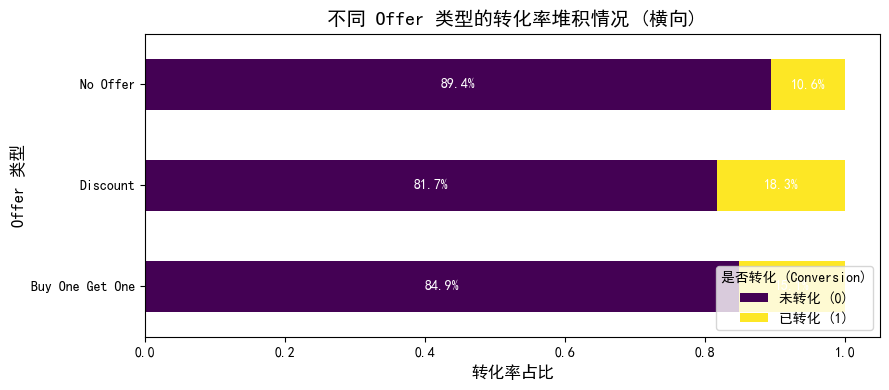

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif']=('SimHei','Microsoft YaHei','WenQuanYi Micro Hei')
# 将 conversion 状态转换为列
pivot_df = result.pivot(index='offer', columns='conversion', values='conversion_rate')

# 3. 绘制【横向】堆积柱状图
ax = pivot_df.plot(
    kind='barh',    
    stacked=True, 
    figsize=(9, 4), 
    colormap='viridis'
)

# 4. 图表美化与标注
ax.set_title('不同 Offer 类型的转化率堆积情况 (横向)', fontsize=14)
ax.set_xlabel('转化率占比', fontsize=12)
ax.set_ylabel('Offer 类型', fontsize=12)
ax.legend(title='是否转化 (Conversion)', labels=['未转化 (0)', '已转化 (1)'], loc='lower right')

# 在色块中心添加具体的转化率百分比标签
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    # 过滤掉宽度过小的色块，避免标签重叠
    if width > 0.01:  
        x, y = p.get_x() + width / 2, p.get_y() + height / 2
        ax.text(x, y, f'{width:.1%}', ha='center', va='center', fontsize=10, color='white', fontweight='bold')

plt.yticks(rotation=0)  # Y轴标签保持水平
plt.tight_layout()
plt.show()

C:\Users\86151\AppData\Local\Temp\ipykernel_23200\1396238437.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


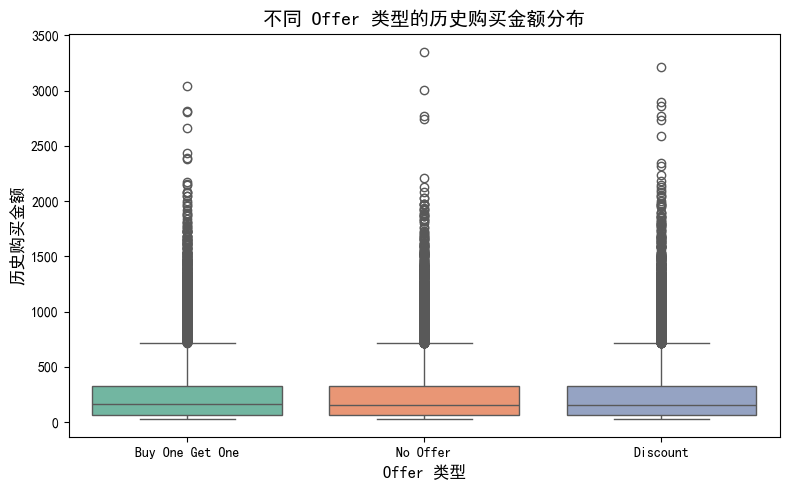

In [40]:
import seaborn as sns


# 2. 绘制箱型图
plt.figure(figsize=(8, 5))  # 设置画布大小
sns.boxplot(
    x='offer',              # X轴：分类变量
    y='history',    # Y轴：数值变量
    data=data,                # 数据源
    palette='Set2'          # 设置配色方案
)

# 3. 图表美化
plt.title('不同 Offer 类型的历史购买金额分布', fontsize=14)
plt.xlabel('Offer 类型', fontsize=12)
plt.ylabel('历史购买金额', fontsize=12)

plt.tight_layout()
plt.show()

In [50]:
#数据预处理
#使用盖帽法处理数据
f_max=data['history'].mean()+3*data['history'].std()
f_min=data['history'].mean()-3*data['history'].std()

data.loc[data['history']>f_max,'history']=f_max
data.loc[data['history']<f_min,'history']=f_min
#数据标准化
from sklearn.preprocessing import StandardScaler, MinMaxScaler

data['zip_code']=data['zip_code'].map({'Surburban':0,'Rural':1,'Urban':2})
data['channel']=data['channel'].map({'Phone':0,'Web':1,'Multichannel':2})
print(data.head())


   recency  history  used_discount  used_bogo  zip_code  is_referral  channel  \
0       10   142.44              1          0         0            0        0   
1        6   329.08              1          1         1            1        1   
2        7   180.65              0          1         0            1        1   
3        9   675.83              1          0         1            1        1   
4        2    45.34              1          0         2            0        1   

             offer  conversion  
0  Buy One Get One           0  
1         No Offer           0  
2  Buy One Get One           0  
3         Discount           0  
4  Buy One Get One           0  


In [ ]:

scaler=MinMaxScaler()
data[['history','zip_code','channel','recency']]=scaler.fit_transform(data[['history','zip_code','channel','recency']])



print(data.head(10))


    recency   history  used_discount  used_bogo  zip_code  is_referral  \
0  0.818182  0.114678              1          0       0.0            0   
1  0.454545  0.305016              1          1       0.5            1   
2  0.545455  0.153645              0          1       0.0            1   
3  0.727273  0.658636              1          0       0.5            1   
4  0.090909  0.015654              1          0       1.0            0   
5  0.454545  0.106917              0          1       0.0            0   
6  0.727273  0.255168              1          0       0.0            1   
7  0.727273  0.016756              0          1       1.0            0   
8  0.727273  0.657861              1          1       0.5            1   
9  0.818182  0.002906              0          1       1.0            1   

   channel            offer  conversion  
0      0.0  Buy One Get One           0  
1      0.5         No Offer           0  
2      0.5  Buy One Get One           0  
3      0.5       

In [53]:
#划分训练集和测试集
# 随机抽取 20% 的数据作为备用集
test_data = data.sample(frac=0.2, random_state=42)

# 从原数据中剔除已抽取的行，剩下的 80% 作为训练集
train_data = data.drop(test_data.index)

In [54]:

#构建模型，预测得那些客户不需要活动也会购买
NO_OFFER = test_data[test_data['offer'] == 'No Offer']
BOGO = test_data[test_data['offer'] == 'Buy One Get One']
DISCOUNT = test_data[test_data['offer'] == 'Discount']

# 1. 数据预处理
NO_x = NO_OFFER.drop(columns=['offer','conversion'])  # 删除不需要的列
BO_x = BOGO.drop(columns=['offer','conversion'])
DI_x = DISCOUNT.drop(columns=['offer','conversion'])
NO_y = NO_OFFER['conversion']
BO_y = BOGO['conversion']   
DI_y = DISCOUNT['conversion']



In [55]:
#使用逻辑回归模型进行预测
from sklearn.linear_model import LogisticRegression

model_NO = LogisticRegression()
model_BO = LogisticRegression()
model_DI = LogisticRegression()

# 拟合模型
model_NO.fit(NO_x, NO_y)
model_BO.fit(BO_x, BO_y)
model_DI.fit(DI_x, DI_y)
print("\n模型训练完成！")


模型训练完成！


In [56]:
test_x=test_data.drop(columns=['offer','conversion'])
test_data['NO_Pred'] = model_NO.predict_proba(test_x)[:, 1]  # 获取预测为1的概率
test_data['BO_Pred'] = model_BO.predict_proba(test_x)[:, 1]
test_data['DI_Pred'] = model_DI.predict_proba(test_x)[:, 1]
print("\n预测完成！")
print(test_data.head())


预测完成！
        recency   history  used_discount  used_bogo  zip_code  is_referral  \
33042  0.727273  0.035551              1          0       0.0            1   
7209   0.000000  0.116391              0          1       1.0            0   
24367  0.000000  0.718214              0          1       0.0            1   
19599  0.272727  1.000000              1          0       0.0            1   
31465  0.090909  0.235822              1          1       0.0            1   

       channel            offer  conversion   NO_Pred   BO_Pred   DI_Pred  
33042      0.5         Discount           0  0.052321  0.082229  0.114689  
7209       0.5         Discount           0  0.147489  0.199260  0.243444  
24367      0.0         Discount           0  0.095098  0.175260  0.180340  
19599      1.0         Discount           1  0.125403  0.157897  0.196874  
31465      0.5  Buy One Get One           1  0.130388  0.276469  0.322287  


In [ ]:
#设定活动能提升5%且营销后转化率高于15%为高营销价值用户

def classify_user(row):
    if (row['NO_Pred']+0.05 > max(row['BO_Pred'], row['DI_Pred']))or max(row['NO_Pred'], row['BO_Pred'], row['DI_Pred']) < 0.15:
        return 'No Offer'
    elif row['BO_Pred'] >= max(row['NO_Pred'], row['DI_Pred']):
        return 'Buy One Get One'
    else:
        return 'Discount'

# axis=1 表示按行处理
test_data['offer_pred'] = test_data.apply(classify_user, axis=1)
print(test_data[['NO_Pred', 'BO_Pred', 'DI_Pred', 'offer_pred']].head())



        NO_Pred   BO_Pred   DI_Pred offer_pred
33042  0.052321  0.082229  0.114689   No Offer
7209   0.147489  0.199260  0.243444   Discount
24367  0.095098  0.175260  0.180340   Discount
19599  0.125403  0.157897  0.196874   Discount
31465  0.130388  0.276469  0.322287   Discount


In [65]:
pred_result=test_data.groupby(['offer_pred','offer','conversion']).size().reset_index()  #分组统计预测效果
pred_result.columns=['offer_pred','offer','conversion','count1']  #重命名列名
pred_result['conversion_rate']=pred_result['count1']/pred_result.groupby(['offer_pred','offer'])['count1'].transform('sum')  #计算每个活动类型的转化率
print(pred_result)

         offer_pred            offer  conversion  count1  conversion_rate
0   Buy One Get One  Buy One Get One           0     327         0.803440
1   Buy One Get One  Buy One Get One           1      80         0.196560
2   Buy One Get One         Discount           0     342         0.830097
3   Buy One Get One         Discount           1      70         0.169903
4   Buy One Get One         No Offer           0     373         0.905340
5   Buy One Get One         No Offer           1      39         0.094660
6          Discount  Buy One Get One           0    2031         0.826954
7          Discount  Buy One Get One           1     425         0.173046
8          Discount         Discount           0    1927         0.771108
9          Discount         Discount           1     572         0.228892
10         Discount         No Offer           0    2208         0.870319
11         Discount         No Offer           1     329         0.129681
12         No Offer  Buy One Get One  

In [68]:
result_pred=pred_result[pred_result['conversion']==True]
pivot_re = result_pred.pivot(index='offer_pred', columns='offer', values='conversion_rate')
print(pivot_re)

offer            Buy One Get One  Discount  No Offer
offer_pred                                          
Buy One Get One         0.196560  0.169903  0.094660
Discount                0.173046  0.228892  0.129681
No Offer                0.097139  0.108494  0.048220


In [66]:
test_data.to_csv(r"D:\pythonfiles\__pycache__\电商营销活动分析\test_data_with_predictions.csv", index=False)